# Preprocessing Discover Graph text data

In [41]:
from neo4j import GraphDatabase, basic_auth
import pandas as pd
import numpy as np
import os
import json
import collections
import sklearn
import stellargraph as sg



In [49]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import tensorflow as tf


import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GAT

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, feature_extraction, model_selection
from stellargraph import datasets
from IPython.display import display, HTML
import matplotlib.pyplot as plt



In [21]:
driver = GraphDatabase.driver( "bolt://localhost:7687",  auth=basic_auth("neo4j", "nindoo123"))

# Pre-Processing Text

In [22]:
pulling_query = """\
            MATCH (a:Text)
            RETURN ID(a) AS ID, a.description AS description
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    blogs_desc = pd.DataFrame([dict(row) for row in result])
print("Shape",blogs_desc.shape)
blogs_desc.head()

Shape (372, 2)


,ID,description
0,360,"And not just in school, but at home Continue r..."
1,380,I have always wondered if a Design system shou...
2,381,Learn the basic concepts behind the most commo...
3,382,Maybe they should all meet the same fate Conti...
4,383,“The current protests are not simply about rac...


In [23]:
pulling_query = """\
            MATCH (a:INTEREST)
            RETURN ID(a) AS ID, a.description AS description
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    interests_desc = pd.DataFrame([dict(row) for row in result])
print("Shape",interests_desc.shape)
interests_desc.head()

Shape (730, 2)


,ID,description
0,0,Web development is the work involved in develo...
1,1,TypeScript is an open-source programming langu...
2,2,A programming language is a formal language co...
3,3,Not Found
4,4,"The career is an individual's metaphorical ""jo..."


In [24]:
descriptions_db = pd.concat([blogs_desc,interests_desc])
descriptions_db['description'].str.encode('utf-8')
print(descriptions_db.shape)
descriptions_db.head()

(1102, 2)


,ID,description
0,360,"And not just in school, but at home Continue r..."
1,380,I have always wondered if a Design system shou...
2,381,Learn the basic concepts behind the most commo...
3,382,Maybe they should all meet the same fate Conti...
4,383,“The current protests are not simply about rac...


In [26]:
corpus_text = ""
for index,r in descriptions_db.iterrows():
    corpus_text += r['description']
with open('corpus.txt','w') as t:
    t.write(corpus_text)
    t.close()

In [27]:
processed_corpus = corpus_text.translate ({ord(c): " " for c in "''!@#$%^&*()[]{};:,./<>?\|`~-=_+"})
list_corpus = corpus_text.split(' ')
print(list_corpus)

 '443', 'in', 'the', 'case', 'of', 'TLS-encrypted', 'connections),', 'which', 'is', 'of', 'benefit', 'for', 'those', 'environments', 'which', 'block', 'non-web', 'Internet', 'connections', 'using', 'a', 'firewall.', 'Similar', 'two-way', 'browser-server', 'communications', 'have', 'been', 'achieved', 'in', 'non-standardized', 'ways', 'using', 'stopgap', 'technologies', 'such', 'as', 'Comet.\nMost', 'browsers', 'support', 'the', 'protocol,', 'including', 'Google', 'Chrome,', 'Microsoft', 'Edge,', 'Internet', 'Explorer,', 'Firefox,', 'Safari', 'and', 'Opera.\n\nApache', 'Kafka', 'is', 'an', 'open-source', 'stream-processing', 'software', 'platform', 'developed', 'by', 'LinkedIn', 'and', 'donated', 'to', 'the', 'Apache', 'Software', 'Foundation,', 'written', 'in', 'Scala', 'and', 'Java.', 'The', 'project', 'aims', 'to', 'provide', 'a', 'unified,', 'high-throughput,', 'low-latency', 'platform', 'for', 'handling', 'real-time', 'data', 'feeds.', 'Kafka', 'can', 'connect', 'to', 'external', '

In [28]:
vocab = list(set(list_corpus)) # This works well for a very small corpus
print(vocab)

'access"', 'reused', 'μ\n', '1963', 'saving', 'ratified', 'triangles', 'Microsoft,', '"nerve', 'Alcimus', 'mass-produced,', 'hard', 'parts.', 'pertaining', 'feasible', 'naturally', 'terminals', 'Numbers', 'ConvNet)', "Money's", 'nature".Racial', 'choice.\nAWS', 'King.', 'thereof,', 'proportional', 'pay,', 'audio', 'User', 'trade/retail', 'women.', 'programming?', '2002)', 'successes', 'sakiehs', 'Network,', 'programs.\n\nIn', '∫\n', '(Amazon', 'ecosystem,', 'disabled.Accessibility', 'excavation', 'Index', 'interpreter,', 'swipe', 'process”', 'mainly', 'censoring', 'marketing.', 'stores.Flutter', 'ago.', 'harmful', 'article', '"pure', 'phenotype,', 'us', 'diary,', 'criticized,', 'Griesemer,', 'identifiable', 'questionable', 'Doug', '7.3', 'effective.', 'constables,', '"lack', 'sign:', 'polymorphism,', 'functionalities.In', 'Muslim', 'Ninja,', 'exclusively', '2016,', 'No.', 'Junio', 'especially', 'dream."', '0.14,', '(sparring),', 'garnered', 'methods,', 'trends', 'Mesoamerica,', 'observ

In [29]:
word_counter = collections.Counter()
for term in list_corpus:
 
    if len(term) > 3:       word_counter.update({term: 1})
vocab = word_counter.most_common(200) # 200 Most common terms
print('Vocab Size: {}'.format(len(vocab))) 
print(word_counter.most_common(100))

Vocab Size: 200
[('that', 1064), ('with', 806), ('from', 572), ('which', 471), ('such', 438), ('data', 434), ('other', 378), ('also', 378), ('have', 354), ('used', 345), ('more', 242), ('most', 233), ('social', 221), ('been', 216), ('software', 213), ('their', 211), ('Continue', 195), ('often', 193), ('many', 190), ('reading', 189), ('including', 180), ('computer', 177), ('design', 176), ('some', 173), ('into', 172), ('through', 169), ('between', 169), ('system', 168), ('than', 167), ('human', 155), ('include', 155), ('using', 154), ('they', 146), ('This', 145), ('known', 144), ('United', 143), ('different', 141), ('called', 141), ('this', 140), ('development', 138), ('language', 135), ('learning', 134), ('systems', 133), ('time', 132), ('programming', 128), ('first', 127), ('term', 125), ('over', 123), ('information', 122), ('form', 121), ('process', 118), ('about', 117), ('were', 114), ('being', 112), ('based', 110), ('these', 109), ('developed', 104), ('part', 102), ('research', 102

In [30]:
vocab.append(('UNKNOWN', 1))
Idx = range(1, len(vocab)+1)
vocab = [t[0] for t in vocab]

Word2Idx = dict(zip(vocab, Idx))
Idx2Word = dict(zip(Idx, vocab))

Word2Idx['PAD'] = 0
Idx2Word[0] = 'PAD'
VOCAB_SIZE = len(Word2Idx)
print('Word2Idx Size: {}'.format(len(Word2Idx)))
print('Idx2Word Size: {}'.format(len(Idx2Word)))

Word2Idx Size: 202
Idx2Word Size: 202
{'that': 1, 'with': 2, 'from': 3, 'which': 4, 'such': 5, 'data': 6, 'other': 7, 'also': 8, 'have': 9, 'used': 10, 'more': 11, 'most': 12, 'social': 13, 'been': 14, 'software': 15, 'their': 16, 'Continue': 17, 'often': 18, 'many': 19, 'reading': 20, 'including': 21, 'computer': 22, 'design': 23, 'some': 24, 'into': 25, 'through': 26, 'between': 27, 'system': 28, 'than': 29, 'human': 30, 'include': 31, 'using': 32, 'they': 33, 'This': 34, 'known': 35, 'United': 36, 'different': 37, 'called': 38, 'this': 39, 'development': 40, 'language': 41, 'learning': 42, 'systems': 43, 'time': 44, 'programming': 45, 'first': 46, 'term': 47, 'over': 48, 'information': 49, 'form': 50, 'process': 51, 'about': 52, 'were': 53, 'being': 54, 'based': 55, 'these': 56, 'developed': 57, 'part': 58, 'research': 59, 'within': 60, 'people': 61, 'well': 62, 'only': 63, 'while': 64, 'when': 65, 'where': 66, 'will': 67, 'series': 68, 'both': 69, 'machine': 70, 'study': 71, 'typic

In [31]:
with open('word2idx.json','w') as w:
    json.dump(Word2Idx,w)
with open('idx2word.json','w') as w:
    json.dump(Idx2Word,w)

In [32]:
w2idx_db = descriptions_db.copy()

In [33]:
w2idx_dict = {}
for index,r in w2idx_db.iterrows():
    processed = r['description'].translate ({ord(c): " " for c in "''!@#$%^&*()[]{};:,./<>?\|`~-=_+"})
    list_doc = processed.split(' ')
    w2i_list = []
    for element in list_doc:
        if element in Word2Idx:
             w2i_list.append(Word2Idx[element])
        else: 
            w2i_list.append(Word2Idx['UNKNOWN'])
    while len(w2i_list) < 100:
       w2i_list.append(Word2Idx['PAD'])
    if len(w2i_list) > 100:
        w2i_list = w2i_list[:100]
    w2idx_dict[r['ID']] = w2i_list


# Creating StellarGraph

### Puxando Edges

In [36]:
pulling_query = """\
            MATCH (a)-->(b)
            RETURN ID(a) AS source, ID(b) AS target
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    edges_db = pd.DataFrame([dict(row) for row in result])
print(edges_db.shape)
edges_db.head()

(2910, 2)


,source,target
0,0,23
1,0,22
2,0,21
3,0,20
4,1,318


### puxando labels

In [58]:
pulling_query = """\
            MATCH (a)
            WHERE EXISTS (a.label)
            RETURN ID(a) AS source, a.label AS subject
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    label_db = pd.DataFrame([dict(row) for row in result])
labels = pd.Series(data =label_db['subject'].values, index = label_db['source'].values)
labels.head()

0    Programming
1    Programming
2    Programming
3    Programming
4    Programming
dtype: object

### cirando banco de dados de features w2idx

In [59]:
features_db = pd.DataFrame.from_dict(w2idx_dict,orient='index')
print(features_db.shape)
features_db.head()

(1102, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
360,201,201,201,201,201,201,201,201,201,17,...,0,0,0,0,0,0,0,0,0,0
380,201,9,201,201,201,201,201,28,201,201,...,0,0,0,0,0,0,0,0,0,0
381,201,201,201,201,201,201,12,83,6,201,...,0,0,0,0,0,0,0,0,0,0
382,201,33,201,201,201,201,79,201,17,20,...,0,0,0,0,0,0,0,0,0,0
383,201,201,201,201,201,201,52,201,201,201,...,0,0,0,0,0,0,0,0,0,0


### Criando grafo

In [60]:
graph = sg.StellarGraph(nodes = {"blog":features_db}, edges =  edges_db)
print(graph.info())

StellarGraph: Undirected multigraph
 Nodes: 1102, Edges: 2910

 Node types:
  blog: [1102]
    Features: float32 vector, length 100
    Edge types: blog-default->blog

 Edge types:
    blog-default->blog: [2910]
        Weights: all 1 (default)
        Features: none


In [61]:
train_subjects, test_subjects = model_selection.train_test_split(
    labels, train_size=140, test_size=None, stratify=labels
)
val_subjects, test_subjects = model_selection.train_test_split(
    test_subjects, train_size=500, test_size=None, stratify=test_subjects
)

In [63]:
from collections import Counter

Counter(train_subjects)

Counter({'ML': 33,
         'Society': 18,
         'Education': 10,
         'Programming': 65,
         'AI': 7,
         'Design': 7})

In [64]:
target_encoding = preprocessing.LabelBinarizer()

train_targets = target_encoding.fit_transform(train_subjects)
val_targets = target_encoding.transform(val_subjects)
test_targets = target_encoding.transform(test_subjects)

In [65]:
generator = FullBatchNodeGenerator(graph, method="gat")

train_gen = generator.flow(train_subjects.index, train_targets)

In [101]:
gat = GAT(
    layer_sizes=[8,train_targets.shape[1]],
    activations=["elu", "softmax"],
    attn_heads=4,
    generator=generator,
    in_dropout=0.5,
    attn_dropout=0.5,
    normalize=None,
)

In [102]:
x_inp, predictions = gat.in_out_tensors()

In [103]:
model = Model(inputs=x_inp, outputs=predictions)
model.compile(
    optimizer=optimizers.Adam(lr=0.005),
    loss=losses.categorical_crossentropy,
    metrics=["acc"],
)

In [104]:
val_gen = generator.flow(val_subjects.index, val_targets)

In [105]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

if not os.path.isdir("logs"):
    os.makedirs("logs")
es_callback = EarlyStopping(
    monitor="val_acc", patience=20
)  # patience is the number of epochs to wait before early stopping in case of no further improvement
mc_callback = ModelCheckpoint(
    "models/best_model.h5", monitor="val_acc", save_best_only=True, save_weights_only=False
)

In [106]:
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_9 (InputLayer)            [(1, 1102, 100)]     0                                            
__________________________________________________________________________________________________
input_11 (InputLayer)           [(1, None, 2)]       0                                            
__________________________________________________________________________________________________
input_12 (InputLayer)           [(1, None)]          0                                            
__________________________________________________________________________________________________
dropout_4 (Dropout)             (1, 1102, 100)       0           input_9[0][0]                    
____________________________________________________________________________________________

In [107]:
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    verbose=2,
    shuffle=False,  # this should be False, since shuffling data means shuffling the whole graph
    callbacks=[mc_callback],
)


Epoch 1/30
1/1 - 0s - loss: 12.9881 - acc: 0.1500 - val_loss: 14.0921 - val_acc: 0.1200
Epoch 2/30
1/1 - 0s - loss: 12.5967 - acc: 0.2000 - val_loss: 14.0327 - val_acc: 0.1260
Epoch 3/30
1/1 - 0s - loss: 12.5815 - acc: 0.1643 - val_loss: 14.0078 - val_acc: 0.1280
Epoch 4/30
1/1 - 0s - loss: 12.2515 - acc: 0.1929 - val_loss: 13.9912 - val_acc: 0.1300
Epoch 5/30
1/1 - 0s - loss: 13.2462 - acc: 0.1571 - val_loss: 13.9575 - val_acc: 0.1320
Epoch 6/30
1/1 - 0s - loss: 12.2559 - acc: 0.2143 - val_loss: 14.1291 - val_acc: 0.1200
Epoch 7/30
1/1 - 0s - loss: 10.9883 - acc: 0.2714 - val_loss: 13.9981 - val_acc: 0.1300
Epoch 8/30
1/1 - 0s - loss: 11.6254 - acc: 0.2286 - val_loss: 14.1071 - val_acc: 0.1240
Epoch 9/30
1/1 - 0s - loss: 12.2071 - acc: 0.2143 - val_loss: 14.1195 - val_acc: 0.1240
Epoch 10/30
1/1 - 0s - loss: 10.7491 - acc: 0.2786 - val_loss: 14.0136 - val_acc: 0.1300
Epoch 11/30
1/1 - 0s - loss: 12.4648 - acc: 0.1786 - val_loss: 13.9905 - val_acc: 0.1320
Epoch 12/30
1/1 - 0s - loss: 1

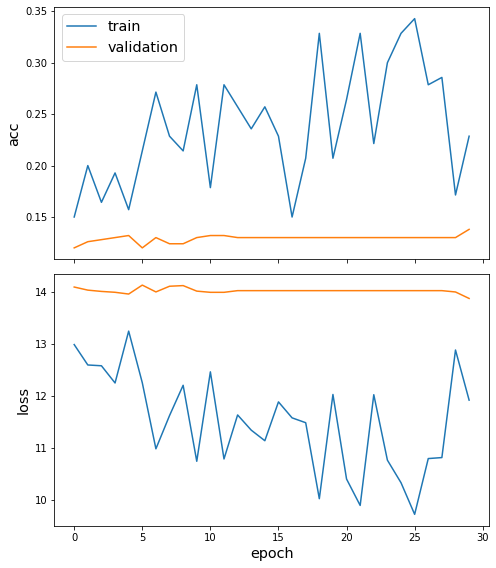

In [108]:
sg.utils.plot_history(history)

In [109]:
test_gen = generator.flow(test_subjects.index, test_targets)
test_metrics = model.evaluate(test_gen)
print("\nTest Set Metrics:")
for name, val in zip(model.metrics_names, test_metrics):
    print("\t{}: {:0.4f}".format(name, val))

1/1 [==============================] - 0s 858us/step - loss: 14.0967 - acc: 0.1214

Test Set Metrics:
	loss: 14.0967
	acc: 0.1214


In [110]:
all_nodes = labels.index
all_gen = generator.flow(all_nodes)
all_predictions = model.predict(all_gen)

In [111]:
node_predictions = target_encoding.inverse_transform(all_predictions.squeeze())

In [112]:
df = pd.DataFrame({"Predicted": node_predictions, "True": labels})
df.head(20)

,Predicted,True
0,Society,Programming
1,Society,Programming
2,Society,Programming
3,Society,Programming
4,Society,Programming
5,Society,Society
6,Society,Education
7,Society,Education
8,Society,Education
9,Society,Education
